In [ ]:
from pathlib import Path  # For working with file system paths
import zipfile  # For extracting zip files
import shutil  # For file operations like removing directories

ZIP_PATH = Path("/content/part2_writer.zip")  # Path to the zip file containing dataset
EXTRACT_ROOT = Path("/content/part2_writer")  # Directory where zip will be extracted

if not ZIP_PATH.exists():  # Check if zip file exists
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")  # Raise error if missing

if EXTRACT_ROOT.exists():  # Remove extracted directory if it already exists
    shutil.rmtree(EXTRACT_ROOT)  # Clean up previous extractions

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)  # Create new extraction directory

with zipfile.ZipFile(ZIP_PATH, "r") as zf:  # Open zip file for reading
    zf.extractall(EXTRACT_ROOT)  # Extract all files to target directory

print("Extraction complete.")  # Confirm extraction is done
print("Top-level contents after extraction:")  # Print header for file listing
for p in sorted(EXTRACT_ROOT.iterdir()):  # Iterate through extracted files
    print("-", p.name)  # Print names of extracted items

# Try to infer the actual dataset root
candidate_roots = [EXTRACT_ROOT] + [p for p in EXTRACT_ROOT.iterdir() if p.is_dir()]  # Create list of possible roots

dataset_root = None  # Initialize dataset root variable
for candidate in candidate_roots:  # Loop through candidate directories
    if (candidate / "training").exists() and (candidate / "testing").exists():  # Check if training and testing folders exist
        dataset_root = candidate  # Found the correct root
        break  # Exit loop once found

if dataset_root is None:  # Verify dataset root was found
    raise RuntimeError("Could not find dataset root containing both 'training' and 'testing' folders.")  # Error if not found

print("\nDetected dataset root:", dataset_root)  # Print the detected dataset root path

Extraction complete.
Top-level contents after extraction:
- __MACOSX
- part2_writer

Detected dataset root: /content/part2_writer/part2_writer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import re

# Update this only if your extracted root is different
DATASET_ROOT = Path("/content/part2_writer/part2_writer")

TRAIN_ROOT = DATASET_ROOT / "training"
TEST_ROOT = DATASET_ROOT / "testing"

OUTPUT_CSV = DATASET_ROOT / "part2_writer_dataset_full.csv"

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
VALID_WRITERS = {"aisha", "ela", "mariam", "noorah", "shaikha"}

# Original old dataset vocabulary
OLD_VOCAB = {"plane", "grain", "jump", "fly", "shout", "brick"}

def parse_filename(filename: str):
    """
    Expected format:
    word_index.png
    example: plane_1.png, book_2.png
    """
    stem = Path(filename).stem.lower().strip()
    match = re.match(r"^([a-z]+)_(\d+)$", stem)
    if not match:
        raise ValueError(f"Filename does not match expected format 'word_index.ext': {filename}")
    transcription = match.group(1)
    repeat_id = int(match.group(2))
    return transcription, repeat_id

rows = []

# ---------- Read training folder ----------
if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f"Missing training folder: {TRAIN_ROOT}")

for writer_dir in sorted(TRAIN_ROOT.iterdir()):
    if not writer_dir.is_dir():
        continue

    writer_id = writer_dir.name.lower().strip()
    if writer_id not in VALID_WRITERS:
        print(f"Warning: skipping unexpected writer folder: {writer_dir}")
        continue

    for image_path in sorted(writer_dir.iterdir()):
        if not image_path.is_file():
            continue
        if image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue

        transcription, repeat_id = parse_filename(image_path.name)

        # Old words inside training belong to old train
        if transcription in OLD_VOCAB:
            source = "old"
            original_split = "train"
            word_key = f"{writer_id}__{transcription}__old_train"
        else:
            # New words inside training belong to new data
            source = "new"
            original_split = "new_train_pool"
            word_key = f"{writer_id}__{transcription}__new"

        rows.append({
            "image_path": str(image_path.resolve()),
            "transcription": transcription,
            "writer_id": writer_id,
            "source": source,
            "original_split": original_split,
            "word_key": word_key,
            "repeat_id": repeat_id,
        })

# ---------- Read testing folder ----------
if not TEST_ROOT.exists():
    raise FileNotFoundError(f"Missing testing folder: {TEST_ROOT}")

for writer_dir in sorted(TEST_ROOT.iterdir()):
    if not writer_dir.is_dir():
        continue

    writer_id = writer_dir.name.lower().strip()
    if writer_id not in VALID_WRITERS:
        print(f"Warning: skipping unexpected writer folder: {writer_dir}")
        continue

    for image_path in sorted(writer_dir.iterdir()):
        if not image_path.is_file():
            continue
        if image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue

        transcription, repeat_id = parse_filename(image_path.name)

        # Old words inside testing belong to original old test
        if transcription in OLD_VOCAB:
            source = "old"
            original_split = "test"
            word_key = f"{writer_id}__{transcription}__old_test"
        else:
            # New words inside testing are still part of the new pool
            source = "new"
            original_split = "new_test_pool"
            word_key = f"{writer_id}__{transcription}__new"

        rows.append({
            "image_path": str(image_path.resolve()),
            "transcription": transcription,
            "writer_id": writer_id,
            "source": source,
            "original_split": original_split,
            "word_key": word_key,
            "repeat_id": repeat_id,
        })

df = pd.DataFrame(rows)

if len(df) == 0:
    raise RuntimeError("No rows found. Check the folder structure and filenames.")

print("Total rows:", len(df))
print("\nRows by source:")
print(df["source"].value_counts())

print("\nRows by original split:")
print(df["original_split"].value_counts())

print("\nRows by writer:")
print(df["writer_id"].value_counts())

print("\nRows by transcription:")
print(df["transcription"].value_counts())

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)

print("\nSaved full dataset CSV to:", OUTPUT_CSV)
display(df.head(20))

Total rows: 260

Rows by source:
source
old    160
new    100
Name: count, dtype: int64

Rows by original split:
original_split
train             150
new_train_pool     80
new_test_pool      20
test               10
Name: count, dtype: int64

Rows by writer:
writer_id
aisha      52
ela        52
mariam     52
noorah     52
shaikha    52
Name: count, dtype: int64

Rows by transcription:
transcription
plane    30
brick    26
jump     26
fly      26
shout    26
grain    26
fish     10
book     10
moon     10
milk     10
hand     10
rain     10
star     10
tree     10
door     10
lamp     10
Name: count, dtype: int64

Saved full dataset CSV to: /content/part2_writer/part2_writer/part2_writer_dataset_full.csv


,image_path,transcription,writer_id,source,original_split,word_key,repeat_id
0,/content/part2_writer/part2_writer/training/ai...,book,aisha,new,new_train_pool,aisha__book__new,1
1,/content/part2_writer/part2_writer/training/ai...,book,aisha,new,new_train_pool,aisha__book__new,2
2,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,1
3,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,2
4,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,3
5,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,4
6,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,5
7,/content/part2_writer/part2_writer/training/ai...,brick,aisha,old,train,aisha__brick__old_train,6
8,/content/part2_writer/part2_writer/training/ai...,fish,aisha,new,new_train_pool,aisha__fish__new,1
9,/content/part2_writer/part2_writer/training/ai...,fish,aisha,new,new_train_pool,aisha__fish__new,2


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

CSV_PATH = Path("/content/part2_writer/part2_writer/part2_writer_dataset_full.csv")

OUTPUT_TRAIN = CSV_PATH.parent / "part2_writer_train_sub.csv"
OUTPUT_VAL = CSV_PATH.parent / "part2_writer_val_sub.csv"
OUTPUT_TEST = CSV_PATH.parent / "part2_writer_test.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

required_cols = {
    "image_path", "transcription", "writer_id",
    "source", "original_split", "word_key", "repeat_id"
}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Verify image paths exist
missing_paths = [p for p in df["image_path"] if not Path(p).exists()]
print("Missing image paths:", len(missing_paths))
if missing_paths:
    print("First few missing paths:")
    for p in missing_paths[:10]:
        print("-", p)
    raise RuntimeError("Some image paths do not exist.")

# Separate old and new data
old_train_df = df[(df["source"] == "old") & (df["original_split"] == "train")].copy()
old_test_df  = df[(df["source"] == "old") & (df["original_split"] == "test")].copy()
new_df       = df[df["source"] == "new"].copy()

print("Old train:", len(old_train_df))
print("Old test :", len(old_test_df))
print("New total:", len(new_df))

# Expectation:
# old_train = 150
# old_test = 10
# new_total = 100

rng = np.random.default_rng(42)

new_train_parts = []
new_val_parts = []
new_test_parts = []

for writer in sorted(new_df["writer_id"].unique()):
    writer_df = new_df[new_df["writer_id"] == writer].copy()

    # Each new word pair should stay together
    word_keys = sorted(writer_df["word_key"].unique())

    if len(word_keys) != 10:
        raise ValueError(
            f"Expected 10 new word-pairs for writer '{writer}', but found {len(word_keys)}"
        )

    shuffled = list(word_keys)
    rng.shuffle(shuffled)

    # per writer:
    # 5 word-pairs -> train = 10 images
    # 3 word-pairs -> val   =  6 images
    # 2 word-pairs -> test  =  4 images
    train_keys = shuffled[:5]
    val_keys   = shuffled[5:8]
    test_keys  = shuffled[8:10]

    new_train_parts.append(writer_df[writer_df["word_key"].isin(train_keys)].copy())
    new_val_parts.append(writer_df[writer_df["word_key"].isin(val_keys)].copy())
    new_test_parts.append(writer_df[writer_df["word_key"].isin(test_keys)].copy())

new_train_df = pd.concat(new_train_parts, ignore_index=True)
new_val_df   = pd.concat(new_val_parts, ignore_index=True)
new_test_df  = pd.concat(new_test_parts, ignore_index=True)

# Final splits:
# old_train = 150 + new_train = 50  -> train = 200
# new_val = 30                      -> val = 30
# old_test = 10 + new_test = 20     -> test = 30
train_df = pd.concat([old_train_df, new_train_df], ignore_index=True)
val_df   = new_val_df.copy()
test_df  = pd.concat([old_test_df, new_test_df], ignore_index=True)

train_df["split"] = "train_sub"
val_df["split"] = "val_sub"
test_df["split"] = "test"

print("\nFinal split sizes:")
print("train:", len(train_df))
print("val  :", len(val_df))
print("test :", len(test_df))

print("\nTrain by writer:")
print(train_df["writer_id"].value_counts())

print("\nVal by writer:")
print(val_df["writer_id"].value_counts())

print("\nTest by writer:")
print(test_df["writer_id"].value_counts())

print("\nTrain by source:")
print(train_df["source"].value_counts())

print("\nVal by source:")
print(val_df["source"].value_counts())

print("\nTest by source:")
print(test_df["source"].value_counts())

train_df.to_csv(OUTPUT_TRAIN, index=False)
val_df.to_csv(OUTPUT_VAL, index=False)
test_df.to_csv(OUTPUT_TEST, index=False)

print("\nSaved:")
print("-", OUTPUT_TRAIN)
print("-", OUTPUT_VAL)
print("-", OUTPUT_TEST)

Missing image paths: 0
Old train: 150
Old test : 10
New total: 100

Final split sizes:
train: 200
val  : 30
test : 30

Train by writer:
writer_id
aisha      40
ela        40
mariam     40
noorah     40
shaikha    40
Name: count, dtype: int64

Val by writer:
writer_id
aisha      6
ela        6
mariam     6
noorah     6
shaikha    6
Name: count, dtype: int64

Test by writer:
writer_id
aisha      6
ela        6
mariam     6
noorah     6
shaikha    6
Name: count, dtype: int64

Train by source:
source
old    150
new     50
Name: count, dtype: int64

Val by source:
source
new    30
Name: count, dtype: int64

Test by source:
source
new    20
old    10
Name: count, dtype: int64

Saved:
- /content/part2_writer/part2_writer/part2_writer_train_sub.csv
- /content/part2_writer/part2_writer/part2_writer_val_sub.csv
- /content/part2_writer/part2_writer/part2_writer_test.csv


In [ ]:
from pathlib import Path
import pandas as pd

TRAIN_CSV = Path("/content/part2_writer/part2_writer/part2_writer_train_sub.csv")
VAL_CSV   = Path("/content/part2_writer/part2_writer/part2_writer_val_sub.csv")
TEST_CSV  = Path("/content/part2_writer/part2_writer/part2_writer_test.csv")

for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing split CSV: {p}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Final split sizes")
print("-" * 30)
print("train:", len(train_df))
print("val  :", len(val_df))
print("test :", len(test_df))

assert len(train_df) == 200, f"Expected train=200, got {len(train_df)}"
assert len(val_df) == 30, f"Expected val=30, got {len(val_df)}"
assert len(test_df) == 30, f"Expected test=30, got {len(test_df)}"

print("\nRows by writer")
print("-" * 30)
print("TRAIN")
print(train_df["writer_id"].value_counts())
print("\nVAL")
print(val_df["writer_id"].value_counts())
print("\nTEST")
print(test_df["writer_id"].value_counts())

print("\nRows by source")
print("-" * 30)
print("TRAIN")
print(train_df["source"].value_counts())
print("\nVAL")
print(val_df["source"].value_counts())
print("\nTEST")
print(test_df["source"].value_counts())

# Check all image paths exist
all_paths = pd.concat([
    train_df[["image_path"]],
    val_df[["image_path"]],
    test_df[["image_path"]],
], ignore_index=True)

missing_paths = [p for p in all_paths["image_path"] if not Path(p).exists()]
print("\nMissing image paths:", len(missing_paths))
if missing_paths:
    print("First few missing paths:")
    for p in missing_paths[:10]:
        print("-", p)
    raise RuntimeError("Some image paths do not exist.")

# Check no image appears in more than one split
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

assert len(train_paths & val_paths) == 0, "Leakage: some images appear in both train and val"
assert len(train_paths & test_paths) == 0, "Leakage: some images appear in both train and test"
assert len(val_paths & test_paths) == 0, "Leakage: some images appear in both val and test"

print("\nNo image-level leakage detected.")

# Check new word-pairs stayed together
# A new word-pair should never be split across train/val/test
combined = pd.concat([
    train_df.assign(final_split="train_sub"),
    val_df.assign(final_split="val_sub"),
    test_df.assign(final_split="test"),
], ignore_index=True)

new_only = combined[combined["source"] == "new"].copy()

pair_split_counts = (
    new_only.groupby("word_key")["final_split"]
    .nunique()
    .reset_index(name="num_splits")
)

bad_pairs = pair_split_counts[pair_split_counts["num_splits"] > 1]

print("New word-pairs split across multiple sets:", len(bad_pairs))
if len(bad_pairs) > 0:
    display(bad_pairs)
    raise RuntimeError("Some new word-pairs were split across multiple sets.")

print("\nNo pair leakage detected for new data.")

# Optional: quick look at words per split
print("\nWords by split")
print("-" * 30)
print("TRAIN")
print(train_df["transcription"].value_counts().sort_index())
print("\nVAL")
print(val_df["transcription"].value_counts().sort_index())
print("\nTEST")
print(test_df["transcription"].value_counts().sort_index())

print("\nVerification passed.")

Final split sizes
------------------------------
train: 200
val  : 30
test : 30

Rows by writer
------------------------------
TRAIN
writer_id
aisha      40
ela        40
mariam     40
noorah     40
shaikha    40
Name: count, dtype: int64

VAL
writer_id
aisha      6
ela        6
mariam     6
noorah     6
shaikha    6
Name: count, dtype: int64

TEST
writer_id
aisha      6
ela        6
mariam     6
noorah     6
shaikha    6
Name: count, dtype: int64

Rows by source
------------------------------
TRAIN
source
old    150
new     50
Name: count, dtype: int64

VAL
source
new    30
Name: count, dtype: int64

TEST
source
new    20
old    10
Name: count, dtype: int64

Missing image paths: 0

No image-level leakage detected.
New word-pairs split across multiple sets: 0

No pair leakage detected for new data.

Words by split
------------------------------
TRAIN
transcription
book      4
brick    24
door      4
fish      6
fly      24
grain    24
hand      4
jump     24
lamp      4
milk      6
moo

In [ ]:
from pathlib import Path
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import torchvision.transforms.functional as TF
import random


class WriterWordDataset(Dataset):
    def __init__(
        self,
        csv_path,
        writer_to_idx=None,
        target_height=64,
        target_width=256,
        return_metadata=False,
        augment=False,
    ):
        self.csv_path = Path(csv_path)
        if not self.csv_path.exists():
            raise FileNotFoundError(f"CSV not found: {self.csv_path}")

        self.df = pd.read_csv(self.csv_path)

        required_cols = {"image_path", "transcription", "writer_id", "split"}
        missing_cols = required_cols - set(self.df.columns)
        if missing_cols:
            raise ValueError(f"Missing required columns in CSV: {missing_cols}")

        self.target_height = target_height
        self.target_width = target_width
        self.return_metadata = return_metadata
        self.augment = augment

        if writer_to_idx is None:
            writers = sorted([w for w in self.df["writer_id"].unique() if w != "unknown"])
            self.writer_to_idx = {writer: idx for idx, writer in enumerate(writers)}
        else:
            self.writer_to_idx = writer_to_idx

        self.idx_to_writer = {idx: writer for writer, idx in self.writer_to_idx.items()}

    def __len__(self):
        return len(self.df)

    def _load_image(self, image_path):
        image_path = Path(image_path)
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        img = Image.open(image_path).convert("L")

        # Light blank-margin trimming
        img_np = np.array(img)
        threshold = 250
        rows = np.where(np.min(img_np, axis=1) < threshold)[0]
        cols = np.where(np.min(img_np, axis=0) < threshold)[0]

        if len(rows) > 0 and len(cols) > 0:
            top, bottom = rows[0], rows[-1]
            left, right = cols[0], cols[-1]
            img_np = img_np[top:bottom + 1, left:right + 1]

        img = Image.fromarray(img_np)

        # Resize by fixed height, preserve aspect ratio
        w, h = img.size
        scale = self.target_height / h
        new_w = max(1, int(round(w * scale)))
        new_h = self.target_height

        if new_w > self.target_width:
            scale = self.target_width / w
            new_w = self.target_width
            new_h = max(1, int(round(h * scale)))

        img = img.resize((new_w, new_h), Image.BILINEAR)

        # White canvas
        canvas = Image.new("L", (self.target_width, self.target_height), color=255)
        paste_x = 0
        paste_y = (self.target_height - new_h) // 2
        canvas.paste(img, (paste_x, paste_y))

        img_np = np.array(canvas).astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img_np).unsqueeze(0)

        return img_tensor

    def _augment_tensor(self, img_tensor):
        # Stronger but still safe writer-preserving augmentation

        # small rotation
        angle = random.uniform(-4, 4)
        img_tensor = TF.rotate(img_tensor, angle=angle, fill=[1.0])

        # small affine: translation + scale
        translate_x = random.uniform(-0.04, 0.04) * self.target_width
        translate_y = random.uniform(-0.04, 0.04) * self.target_height
        scale = random.uniform(0.93, 1.07)

        img_tensor = TF.affine(
            img_tensor,
            angle=0.0,
            translate=(int(translate_x), int(translate_y)),
            scale=scale,
            shear=0.0,
            fill=[1.0],
        )

        # light gaussian noise
        if random.random() < 0.6:
            noise = torch.randn_like(img_tensor) * 0.025
            img_tensor = torch.clamp(img_tensor + noise, 0.0, 1.0)

        # light brightness/contrast jitter on grayscale tensor
        if random.random() < 0.4:
            factor = random.uniform(0.9, 1.1)
            img_tensor = torch.clamp(img_tensor * factor, 0.0, 1.0)

        return img_tensor

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        transcription = str(row["transcription"]).strip().lower()
        writer_id = str(row["writer_id"]).strip().lower()
        split = str(row["split"]).strip()

        image_tensor = self._load_image(image_path)

        if self.augment:
            image_tensor = self._augment_tensor(image_tensor)

        if writer_id in self.writer_to_idx:
            writer_label = self.writer_to_idx[writer_id]
        else:
            writer_label = -1

        if self.return_metadata:
            return {
                "image": image_tensor,
                "writer_label": writer_label,
                "writer_id": writer_id,
                "transcription": transcription,
                "image_path": image_path,
                "split": split,
            }

        return image_tensor, writer_label

In [ ]:
from torch.utils.data import DataLoader

train_dataset = WriterWordDataset(
    csv_path="/content/part2_writer/part2_writer/part2_writer_train_sub.csv",
    return_metadata=False,
    augment=True,
)

val_dataset = WriterWordDataset(
    csv_path="/content/part2_writer/part2_writer/part2_writer_val_sub.csv",
    writer_to_idx=train_dataset.writer_to_idx,
    return_metadata=False,
    augment=False,
)

test_dataset = WriterWordDataset(
    csv_path="/content/part2_writer/part2_writer/part2_writer_test.csv",
    writer_to_idx=train_dataset.writer_to_idx,
    return_metadata=False,
    augment=False,
)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Writer mapping:", train_dataset.writer_to_idx)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Writer mapping: {'aisha': 0, 'ela': 1, 'mariam': 2, 'noorah': 3, 'shaikha': 4}
Train: 200
Val: 30
Test: 30


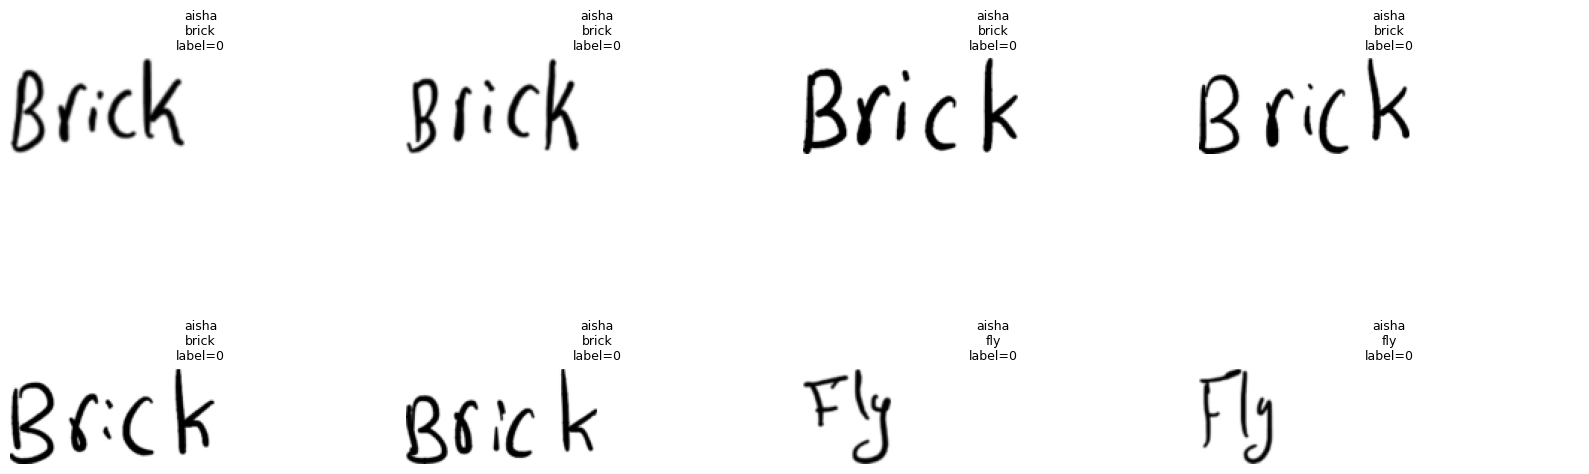

In [ ]:
import matplotlib.pyplot as plt

train_dataset_debug = WriterWordDataset(
    csv_path="/content/part2_writer/part2_writer/part2_writer_train_sub.csv",
    writer_to_idx=train_dataset.writer_to_idx,
    return_metadata=True,
    augment=False
)

num_samples = min(8, len(train_dataset_debug))

plt.figure(figsize=(16, 8))
for i in range(num_samples):
    sample = train_dataset_debug[i]
    img = sample["image"].squeeze(0).numpy()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f'{sample["writer_id"]}\n{sample["transcription"]}\nlabel={sample["writer_label"]}',
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WriterCNN(nn.Module):
    def __init__(self, num_writers=5, embedding_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.embedding_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.45),
        )

        self.classifier = nn.Linear(embedding_dim, num_writers)

    def forward(self, x, return_embedding=False, normalize_embedding=False):
        x = self.features(x)
        x = self.pool(x)
        embedding = self.embedding_layer(x)

        if normalize_embedding:
            embedding = F.normalize(embedding, p=2, dim=1)

        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding
        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WriterCNN(
    num_writers=len(train_dataset.writer_to_idx),
    embedding_dim=64
).to(device)

print(model)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

WriterCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from pathlib import Path
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WriterCNN(
    num_writers=len(train_dataset.writer_to_idx),
    embedding_dim=64
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=6e-4,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

NUM_EPOCHS = 40
PATIENCE = 8

best_val_f1 = -1.0
best_val_acc = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_state_dict = None

checkpoint_path = Path("/content/best_writer_cnn_v3.pt")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": [],
}

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, acc, macro_f1

In [ ]:
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    improved = val_f1 > best_val_f1

    if improved:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_state_dict = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": best_state_dict,
                "writer_to_idx": train_dataset.writer_to_idx,
                "best_val_f1": best_val_f1,
                "best_val_acc": best_val_acc,
                "embedding_dim": 64,
            },
            checkpoint_path,
        )

        print(f"  -> Saved new best checkpoint to {checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

print("\nTraining complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best val accuracy: {best_val_acc:.4f}")
print(f"Best val macro F1: {best_val_f1:.4f}")

Epoch 01/40 | Train Loss: 1.4017 | Val Loss: 1.6756 | Val Acc: 0.2000 | Val Macro F1: 0.0667 | LR: 0.000600
  -> Saved new best checkpoint to /content/best_writer_cnn_v3.pt
Epoch 02/40 | Train Loss: 1.1593 | Val Loss: 1.5178 | Val Acc: 0.3000 | Val Macro F1: 0.2061 | LR: 0.000600
  -> Saved new best checkpoint to /content/best_writer_cnn_v3.pt
Epoch 03/40 | Train Loss: 1.0385 | Val Loss: 1.0555 | Val Acc: 0.6000 | Val Macro F1: 0.4700 | LR: 0.000600
  -> Saved new best checkpoint to /content/best_writer_cnn_v3.pt
Epoch 04/40 | Train Loss: 0.9332 | Val Loss: 0.8268 | Val Acc: 0.8000 | Val Macro F1: 0.7829 | LR: 0.000600
  -> Saved new best checkpoint to /content/best_writer_cnn_v3.pt
Epoch 05/40 | Train Loss: 0.8584 | Val Loss: 0.7676 | Val Acc: 0.7000 | Val Macro F1: 0.6400 | LR: 0.000600
  -> No improvement for 1 epoch(s)
Epoch 06/40 | Train Loss: 0.7924 | Val Loss: 0.6751 | Val Acc: 0.8667 | Val Macro F1: 0.8652 | LR: 0.000600
  -> Saved new best checkpoint to /content/best_writer_cn

In [ ]:
import torch

pth_path = "/content/writer_identification_model.pth"

torch.save(
    {
        "epoch": best_epoch,
        "model_state_dict": best_state_dict if best_state_dict is not None else model.state_dict(),
        "writer_to_idx": train_dataset.writer_to_idx,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "embedding_dim": 128,
    },
    pth_path,
)

print("Saved model to:", pth_path)

Saved model to: /content/writer_identification_model.pth


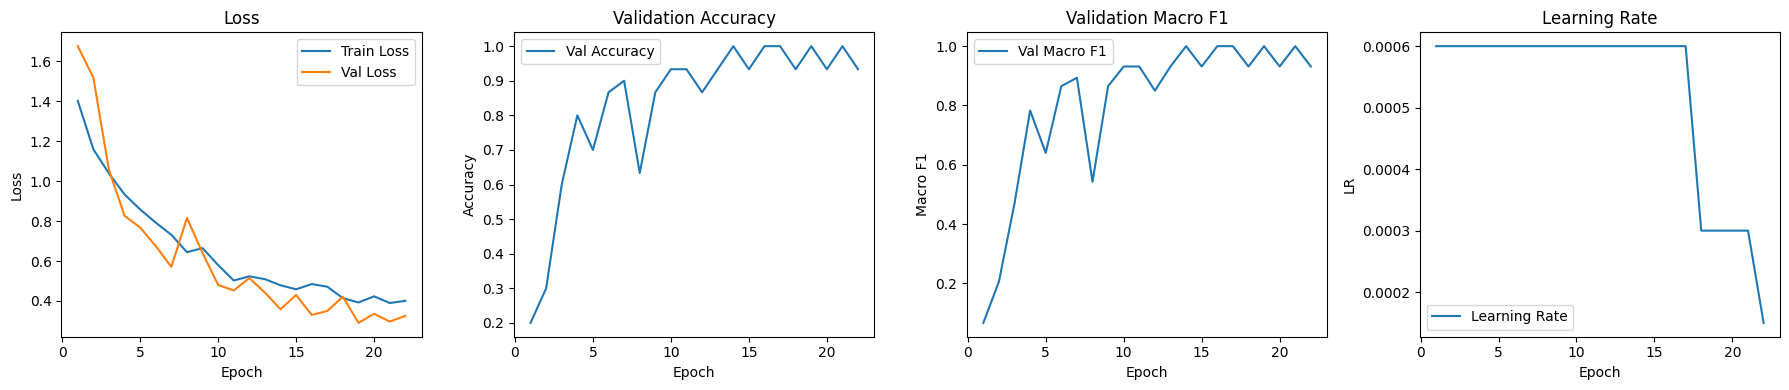

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(epochs, history["val_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1")
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(epochs, history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch  # PyTorch library
import torch.nn as nn  # Neural network module
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report  # Evaluation metrics
import pandas as pd  # For DataFrames
import numpy as np  # For numerical operations

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Determine device

checkpoint_path = "/content/best_writer_cnn_v3.pt"  # Path to saved model
checkpoint = torch.load(checkpoint_path, map_location=device)  # Load checkpoint

print("Loaded checkpoint from:", checkpoint_path)  # Print confirmation
print("Best epoch:", checkpoint["epoch"])  # Print best epoch
print("Best val accuracy:", checkpoint["best_val_acc"])  # Print best accuracy
print("Best val macro F1:", checkpoint["best_val_f1"])  # Print best F1

writer_to_idx = checkpoint["writer_to_idx"]  # Get writer mapping
idx_to_writer = {idx: writer for writer, idx in writer_to_idx.items()}  # Create reverse mapping

print("Writer mapping:", writer_to_idx)  # Print mapping

Loaded checkpoint from: /content/best_writer_cnn_v3.pt
Best epoch: 14
Best val accuracy: 1.0
Best val macro F1: 1.0
Writer mapping: {'aisha': 0, 'ela': 1, 'mariam': 2, 'noorah': 3, 'shaikha': 4}


In [ ]:
model = WriterCNN(  # Create model instance
    num_writers=len(writer_to_idx),  # Number of writer classes
    embedding_dim=checkpoint.get("embedding_dim", 128)  # Embedding dimension from checkpoint
).to(device)  # Move to device

model.load_state_dict(checkpoint["model_state_dict"])  # Load saved weights
model.eval()  # Set to evaluation mode

criterion = nn.CrossEntropyLoss()  # Loss function

In [ ]:
from torch.utils.data import DataLoader  # For batch loading

test_dataset = WriterWordDataset(  # Create test dataset
    csv_path="/content/part2_writer/part2_writer/part2_writer_test.csv",  # Test data path
    writer_to_idx=writer_to_idx,  # Use same writer mapping
    return_metadata=True,  # Include metadata for analysis
    augment=False,  # No augmentation for test
)

test_loader = DataLoader(  # Create test data loader
    test_dataset,  # Test dataset
    batch_size=16,  # Batch size
    shuffle=False,  # Don't shuffle test data
    num_workers=0  # Single worker
)

print("Test samples:", len(test_dataset))  # Print test set size

Test samples: 30


In [ ]:
all_preds = []  # Store all predictions
all_labels = []  # Store all true labels
all_paths = []  # Store all image paths
all_words = []  # Store all transcriptions
running_loss = 0.0  # Initialize loss accumulator

with torch.no_grad():  # Disable gradients for efficiency
    for batch in test_loader:  # Loop through test batches
        images = batch["image"].to(device)  # Get images to device

        # safer handling for batched labels
        if isinstance(batch["writer_label"], torch.Tensor):  # Check if tensor
            labels = batch["writer_label"].to(device)  # Move to device
        else:  # If not tensor
            labels = torch.tensor(batch["writer_label"], dtype=torch.long, device=device)  # Convert to tensor

        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss

        preds = outputs.argmax(dim=1)  # Get predicted class

        running_loss += loss.item() * images.size(0)  # Accumulate loss

        all_preds.extend(preds.cpu().tolist())  # Store predictions
        all_labels.extend(labels.cpu().tolist())  # Store labels
        all_paths.extend(batch["image_path"])  # Store paths
        all_words.extend(batch["transcription"])  # Store words

test_loss = running_loss / len(test_loader.dataset)  # Calculate average loss
test_acc = accuracy_score(all_labels, all_preds)  # Calculate accuracy
test_macro_f1 = f1_score(all_labels, all_preds, average="macro")  # Calculate F1

print(f"Test Loss      : {test_loss:.4f}")  # Print test loss
print(f"Test Accuracy  : {test_acc:.4f}")  # Print test accuracy
print(f"Test Macro F1  : {test_macro_f1:.4f}")  # Print test F1

Test Loss      : 0.3408
Test Accuracy  : 0.9333
Test Macro F1  : 0.9314


In [ ]:
cm = confusion_matrix(all_labels, all_preds)  # Generate confusion matrix

cm_df = pd.DataFrame(  # Convert to DataFrame for better display
    cm,  # Confusion matrix
    index=[idx_to_writer[i] for i in range(len(idx_to_writer))],  # Row labels (true labels)
    columns=[idx_to_writer[i] for i in range(len(idx_to_writer))]  # Column labels (predicted labels)
)

print("Confusion Matrix:")  # Print header
display(cm_df)  # Display matrix

Confusion Matrix:


,aisha,ela,mariam,noorah,shaikha
aisha,4,0,0,0,2
ela,0,6,0,0,0
mariam,0,0,6,0,0
noorah,0,0,0,6,0
shaikha,0,0,0,0,6


In [ ]:
report = classification_report(  # Generate detailed classification report
    all_labels,  # True labels
    all_preds,  # Predicted labels
    target_names=[idx_to_writer[i] for i in range(len(idx_to_writer))],  # Writer names
    digits=4,  # 4 decimal places
    zero_division=0  # Handle zero division gracefully
)

print(report)  # Print report

              precision    recall  f1-score   support

       aisha     1.0000    0.6667    0.8000         6
         ela     1.0000    1.0000    1.0000         6
      mariam     1.0000    1.0000    1.0000         6
      noorah     1.0000    1.0000    1.0000         6
     shaikha     0.7500    1.0000    0.8571         6

    accuracy                         0.9333        30
   macro avg     0.9500    0.9333    0.9314        30
weighted avg     0.9500    0.9333    0.9314        30



In [ ]:
per_writer_stats = []  # List to store per-writer statistics

for writer_idx, writer_name in idx_to_writer.items():  # Loop through each writer
    mask = [label == writer_idx for label in all_labels]  # Create mask for this writer's samples
    writer_true = [t for t, m in zip(all_labels, mask) if m]  # Get true labels for this writer
    writer_pred = [p for p, m in zip(all_preds, mask) if m]  # Get predictions for this writer

    if len(writer_true) == 0:  # Skip if no samples for this writer
        continue

    writer_acc = accuracy_score(writer_true, writer_pred)  # Calculate accuracy for this writer

    per_writer_stats.append({  # Add to statistics
        "writer_id": writer_name,  # Writer name
        "num_samples": len(writer_true),  # Number of samples
        "accuracy": writer_acc,  # Accuracy for this writer
    })

per_writer_df = pd.DataFrame(per_writer_stats).sort_values("writer_id")  # Create DataFrame
display(per_writer_df)  # Display results

,writer_id,num_samples,accuracy
0,aisha,6,0.666667
1,ela,6,1.000000
2,mariam,6,1.000000
3,noorah,6,1.000000
4,shaikha,6,1.000000


In [ ]:
results_df = pd.DataFrame({  # Create results DataFrame
    "image_path": all_paths,  # Image file paths
    "transcription": all_words,  # Words transcribed
    "true_writer_idx": all_labels,  # True writer indices
    "pred_writer_idx": all_preds,  # Predicted writer indices
})

results_df["true_writer"] = results_df["true_writer_idx"].map(idx_to_writer)  # Map indices to writer names
results_df["pred_writer"] = results_df["pred_writer_idx"].map(idx_to_writer)  # Map indices to writer names
results_df["correct"] = results_df["true_writer"] == results_df["pred_writer"]  # Mark correct predictions

display(results_df)  # Display results table

,image_path,transcription,true_writer_idx,pred_writer_idx,true_writer,pred_writer,correct
0,/content/part2_writer/part2_writer/testing/ais...,grain,0,4,aisha,shaikha,False
1,/content/part2_writer/part2_writer/testing/ais...,grain,0,0,aisha,aisha,True
2,/content/part2_writer/part2_writer/testing/ela...,jump,1,1,ela,ela,True
3,/content/part2_writer/part2_writer/testing/ela...,jump,1,1,ela,ela,True
4,/content/part2_writer/part2_writer/testing/mar...,brick,2,2,mariam,mariam,True
5,/content/part2_writer/part2_writer/testing/mar...,brick,2,2,mariam,mariam,True
6,/content/part2_writer/part2_writer/testing/noo...,shout,3,3,noorah,noorah,True
7,/content/part2_writer/part2_writer/testing/noo...,shout,3,3,noorah,noorah,True
8,/content/part2_writer/part2_writer/testing/sha...,fly,4,4,shaikha,shaikha,True
9,/content/part2_writer/part2_writer/testing/sha...,fly,4,4,shaikha,shaikha,True


In [ ]:
wrong_df = results_df[~results_df["correct"]].copy()  # Filter to incorrect predictions

print("Number of wrong predictions:", len(wrong_df))  # Print count
display(wrong_df)  # Display wrong predictions

Number of wrong predictions: 2


,image_path,transcription,true_writer_idx,pred_writer_idx,true_writer,pred_writer,correct
0,/content/part2_writer/part2_writer/testing/ais...,grain,0,4,aisha,shaikha,False
10,/content/part2_writer/part2_writer/training/ai...,star,0,4,aisha,shaikha,False


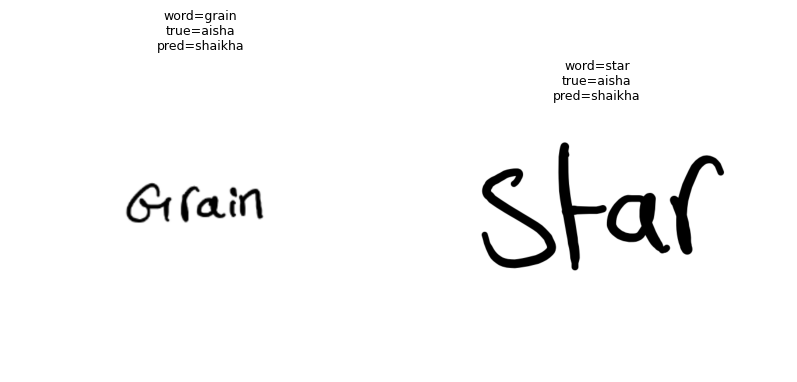

In [ ]:
import matplotlib.pyplot as plt  # For visualization
from PIL import Image  # For loading images

num_show = min(8, len(wrong_df))  # Show minimum of 8 or available errors

if num_show == 0:  # Check if there are any errors
    print("No wrong predictions to display.")  # Message if all correct
else:  # If there are errors
    plt.figure(figsize=(16, 8))  # Create figure
    for i, (_, row) in enumerate(wrong_df.head(num_show).iterrows(), start=1):  # Loop through wrong predictions
        img = Image.open(row["image_path"]).convert("L")  # Load image in grayscale

        plt.subplot(2, 4, i)  # Create subplot
        plt.imshow(img, cmap="gray")  # Display image
        plt.title(  # Set title
            f'word={row["transcription"]}\ntrue={row["true_writer"]}\npred={row["pred_writer"]}',  # Show word, true, predicted
            fontsize=9  # Small font
        )
        plt.axis("off")  # Hide axes

    plt.tight_layout()  # Adjust spacing
    plt.show()  # Display plot

In [ ]:
import torch  # PyTorch library
import torch.nn as nn  # Neural network module
import pandas as pd  # For DataFrames
import numpy as np  # For numerical operations
from torch.utils.data import DataLoader  # For batch loading

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Determine device

checkpoint_path = "/content/best_writer_cnn_v3.pt"  # Path to saved model
checkpoint = torch.load(checkpoint_path, map_location=device)  # Load checkpoint

writer_to_idx = checkpoint["writer_to_idx"]  # Get writer mapping
idx_to_writer = {idx: writer for writer, idx in writer_to_idx.items()}  # Create reverse mapping

model = WriterCNN(  # Create model
    num_writers=len(writer_to_idx),  # Number of writers
    embedding_dim=checkpoint.get("embedding_dim", 128)  # Embedding dimension
).to(device)  # Move to device

model.load_state_dict(checkpoint["model_state_dict"])  # Load weights
model.eval()  # Set to evaluation mode

print("Loaded checkpoint from:", checkpoint_path)  # Confirm load
print("Writer mapping:", writer_to_idx)  # Print mapping

Loaded checkpoint from: /content/best_writer_cnn_v3.pt
Writer mapping: {'aisha': 0, 'ela': 1, 'mariam': 2, 'noorah': 3, 'shaikha': 4}


In [ ]:
train_embed_dataset = WriterWordDataset(  # Create training dataset for embeddings
    csv_path="/content/part2_writer/part2_writer/part2_writer_train_sub.csv",  # Training data
    writer_to_idx=writer_to_idx,  # Writer mapping
    return_metadata=True,  # Include metadata
    augment=False,  # No augmentation
)

val_embed_dataset = WriterWordDataset(  # Create validation dataset for embeddings
    csv_path="/content/part2_writer/part2_writer/part2_writer_val_sub.csv",  # Validation data
    writer_to_idx=writer_to_idx,  # Writer mapping
    return_metadata=True,  # Include metadata
    augment=False,  # No augmentation
)

train_embed_loader = DataLoader(  # Create training loader
    train_embed_dataset,  # Training dataset
    batch_size=16,  # Batch size
    shuffle=False,  # Don't shuffle
    num_workers=0  # Single worker
)

val_embed_loader = DataLoader(  # Create validation loader
    val_embed_dataset,  # Validation dataset
    batch_size=16,  # Batch size
    shuffle=False,  # Don't shuffle
    num_workers=0  # Single worker
)

print("Train_sub samples:", len(train_embed_dataset))  # Print training size
print("Val_sub samples:", len(val_embed_dataset))  # Print validation size

Train_sub samples: 200
Val_sub samples: 30


In [ ]:
def extract_embeddings(model, loader, device):  # Extract embeddings from model
    model.eval()  # Set to evaluation mode

    all_embeddings = []  # Store embeddings
    all_writer_labels = []  # Store labels
    all_writer_ids = []  # Store writer names
    all_paths = []  # Store image paths
    all_words = []  # Store transcriptions

    with torch.no_grad():  # No gradient computation
        for batch in loader:  # Loop through batches
            images = batch["image"].to(device)  # Get images

            if isinstance(batch["writer_label"], torch.Tensor):  # Check if tensor
                labels = batch["writer_label"].to(device)  # Move to device
            else:  # If not
                labels = torch.tensor(batch["writer_label"], dtype=torch.long, device=device)  # Convert

            logits, embeddings = model(images, return_embedding=True)  # Get embeddings from model

            all_embeddings.append(embeddings.cpu())  # Store embeddings on CPU
            all_writer_labels.extend(labels.cpu().tolist())  # Store labels
            all_writer_ids.extend(batch["writer_id"])  # Store writer names
            all_paths.extend(batch["image_path"])  # Store paths
            all_words.extend(batch["transcription"])  # Store words

    all_embeddings = torch.cat(all_embeddings, dim=0)  # Concatenate all embeddings

    return {  # Return dictionary with all data
        "embeddings": all_embeddings,  # Embeddings tensor
        "writer_labels": all_writer_labels,  # Writer label indices
        "writer_ids": all_writer_ids,  # Writer name strings
        "image_paths": all_paths,  # Image paths
        "transcriptions": all_words,  # Word transcriptions
    }

In [ ]:
train_embed_data = extract_embeddings(model, train_embed_loader, device)  # Extract training embeddings
val_embed_data = extract_embeddings(model, val_embed_loader, device)  # Extract validation embeddings

print("Train embeddings shape:", train_embed_data["embeddings"].shape)  # Print shape
print("Val embeddings shape:", val_embed_data["embeddings"].shape)  # Print shape

Train embeddings shape: torch.Size([200, 64])
Val embeddings shape: torch.Size([30, 64])


In [ ]:
def build_writer_prototypes(embeddings, writer_labels):  # Build prototype for each writer
    prototypes = {}  # Dictionary to store prototypes

    embeddings_np = embeddings.numpy()  # Convert embeddings to numpy
    writer_labels_np = np.array(writer_labels)  # Convert labels to numpy

    for writer_label in sorted(np.unique(writer_labels_np)):  # Loop through each writer
        mask = writer_labels_np == writer_label  # Create mask for this writer
        writer_embeds = embeddings_np[mask]  # Get all embeddings for this writer
        prototype = writer_embeds.mean(axis=0)  # Calculate mean embedding (prototype)
        prototypes[writer_label] = prototype  # Store prototype

    return prototypes  # Return all prototypes

In [ ]:
writer_prototypes = build_writer_prototypes(  # Build prototypes
    train_embed_data["embeddings"],  # Training embeddings
    train_embed_data["writer_labels"]  # Training labels
)

print("Built prototypes for:")  # Print header
for label, proto in writer_prototypes.items():  # Loop through prototypes
    print(f"  {label} -> {idx_to_writer[label]}, shape={proto.shape}")  # Print info

Built prototypes for:
  0 -> aisha, shape=(64,)
  1 -> ela, shape=(64,)
  2 -> mariam, shape=(64,)
  3 -> noorah, shape=(64,)
  4 -> shaikha, shape=(64,)


In [ ]:
import torch

prototypes_path = "/content/writer_prototypes.pt"
torch.save(writer_prototypes, prototypes_path)

print("Saved prototypes to:", prototypes_path)

Saved prototypes to: /content/writer_prototypes.pt


In [ ]:
def euclidean_distance(a, b):  # Calculate Euclidean distance
    return np.linalg.norm(a - b)  # Distance formula


def predict_writer_by_prototype(embedding, prototypes):  # Predict writer from embedding
    """
    Returns:
    - best_writer_label
    - best_distance
    - all_distances dict
    """
    embedding = np.asarray(embedding)  # Ensure numpy array

    distances = {}  # Store distances to each prototype
    for writer_label, prototype in prototypes.items():  # Loop through writers
        distances[writer_label] = euclidean_distance(embedding, prototype)  # Calculate distance

    best_writer_label = min(distances, key=distances.get)  # Find closest writer
    best_distance = distances[best_writer_label]  # Get distance to closest

    return best_writer_label, best_distance, distances  # Return results

In [ ]:
from sklearn.metrics import accuracy_score, f1_score  # Evaluation metrics

val_proto_preds = []  # Store predictions from prototypes
val_true_labels = []  # Store true labels
val_best_distances = []  # Store distances to nearest prototype

val_embeddings_np = val_embed_data["embeddings"].numpy()  # Convert to numpy

for emb, true_label in zip(val_embeddings_np, val_embed_data["writer_labels"]):  # Loop through validation set
    pred_label, best_dist, _ = predict_writer_by_prototype(emb, writer_prototypes)  # Get prediction
    val_proto_preds.append(pred_label)  # Store prediction
    val_true_labels.append(true_label)  # Store true label
    val_best_distances.append(best_dist)  # Store distance

val_proto_acc = accuracy_score(val_true_labels, val_proto_preds)  # Calculate accuracy
val_proto_f1 = f1_score(val_true_labels, val_proto_preds, average="macro")  # Calculate F1

print(f"Prototype-only Val Accuracy : {val_proto_acc:.4f}")  # Print accuracy
print(f"Prototype-only Val Macro F1 : {val_proto_f1:.4f}")  # Print F1

Prototype-only Val Accuracy : 0.9333
Prototype-only Val Macro F1 : 0.9314


In [ ]:
val_best_distances = np.array(val_best_distances)  # Convert to numpy array

print("Known validation distance stats:")  # Print header
print("min   :", val_best_distances.min())  # Minimum distance
print("max   :", val_best_distances.max())  # Maximum distance
print("mean  :", val_best_distances.mean())  # Mean distance
print("std   :", val_best_distances.std())  # Standard deviation
print("p50   :", np.percentile(val_best_distances, 50))  # 50th percentile
print("p75   :", np.percentile(val_best_distances, 75))  # 75th percentile
print("p90   :", np.percentile(val_best_distances, 90))  # 90th percentile
print("p95   :", np.percentile(val_best_distances, 95))  # 95th percentile
print("p99   :", np.percentile(val_best_distances, 99))  # 99th percentile

Known validation distance stats:
min   : 1.3800979
max   : 7.5660186
mean  : 3.2088628
std   : 1.5526782
p50   : 2.7299314
p75   : 3.6748667
p90   : 5.4539657
p95   : 6.6415157
p99   : 7.5549183


In [ ]:
from pathlib import Path  # For file paths
import zipfile  # For zip operations
import shutil  # For file operations

ZIP_PATH = Path("/content/unknown_writer.zip")  # Path to unknown writer zip
EXTRACT_ROOT = Path("/content/unknown_writer")  # Extraction directory

if not ZIP_PATH.exists():  # Check if zip exists
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")  # Error if missing

if EXTRACT_ROOT.exists():  # Remove if already extracted
    shutil.rmtree(EXTRACT_ROOT)  # Delete directory

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)  # Create extraction directory

with zipfile.ZipFile(ZIP_PATH, "r") as zf:  # Open zip for reading
    zf.extractall(EXTRACT_ROOT)  # Extract all files

print("Extraction complete.")  # Confirm extraction
print("Top-level contents:")  # Print header
for p in sorted(EXTRACT_ROOT.iterdir()):  # Iterate through extracted items
    print("-", p.name)  # Print names

# detect actual dataset root
candidate_roots = [EXTRACT_ROOT] + [p for p in EXTRACT_ROOT.iterdir() if p.is_dir()]  # Create list of candidates
unknown_root = None  # Initialize root variable

for candidate in candidate_roots:  # Loop through candidates
    image_files = list(candidate.glob("*.png")) + list(candidate.glob("*.jpg")) + list(candidate.glob("*.jpeg"))  # Find image files
    if len(image_files) > 0:  # If images found
        unknown_root = candidate  # Set as root
        break  # Exit loop

if unknown_root is None:  # Check if root found
    raise RuntimeError("Could not find extracted unknown image folder.")  # Error if not found

print("\nDetected unknown root:", unknown_root)  # Print detected root

Extraction complete.
Top-level contents:
- __MACOSX
- unkown_writer

Detected unknown root: /content/unknown_writer/unkown_writer


In [ ]:
from pathlib import Path  # For file paths
import pandas as pd  # For DataFrames
import re  # For regex

UNKNOWN_ROOT = unknown_root  # Set unknown root
OUTPUT_UNKNOWN_CSV = UNKNOWN_ROOT / "unknown_writer_dataset.csv"  # Output CSV path

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}  # Valid image formats

def parse_word_from_filename(filename: str) -> str:  # Extract word from filename
    stem = Path(filename).stem.lower().strip()  # Get stem, lowercase
    match = re.match(r"^([a-z]+)_(\d+)$", stem)  # Match word_number pattern
    if not match:  # Check if matches
        raise ValueError(f"Filename does not match expected format 'word_index.ext': {filename}")  # Error if not
    return match.group(1)  # Return word

rows = []  # Initialize rows list

for image_path in sorted(UNKNOWN_ROOT.iterdir()):  # Loop through files
    if not image_path.is_file():  # Skip non-files
        continue
    if image_path.suffix.lower() not in VALID_EXTENSIONS:  # Skip non-images
        continue

    transcription = parse_word_from_filename(image_path.name)  # Get word from filename

    rows.append({  # Add row
        "image_path": str(image_path.resolve()),  # Full path
        "transcription": transcription,  # Word
        "writer_id": "unknown",  # Mark as unknown
        "split": "unknown_eval",  # Mark as evaluation set
    })

if not rows:  # Check if any rows
    raise RuntimeError("No unknown images found.")  # Error if empty

unknown_df = pd.DataFrame(rows)  # Create DataFrame
unknown_df.to_csv(OUTPUT_UNKNOWN_CSV, index=False)  # Save CSV

print("Saved unknown CSV to:", OUTPUT_UNKNOWN_CSV)  # Confirm save
display(unknown_df)  # Display data

Saved unknown CSV to: /content/unknown_writer/unkown_writer/unknown_writer_dataset.csv


,image_path,transcription,writer_id,split
0,/content/unknown_writer/unkown_writer/black_1.png,black,unknown,unknown_eval
1,/content/unknown_writer/unkown_writer/black_2.png,black,unknown,unknown_eval
2,/content/unknown_writer/unkown_writer/drive_1.png,drive,unknown,unknown_eval
3,/content/unknown_writer/unkown_writer/drive_2.png,drive,unknown,unknown_eval
4,/content/unknown_writer/unkown_writer/light_1.png,light,unknown,unknown_eval
5,/content/unknown_writer/unkown_writer/light_2.png,light,unknown,unknown_eval
6,/content/unknown_writer/unkown_writer/paper_1.png,paper,unknown,unknown_eval
7,/content/unknown_writer/unkown_writer/paper_2.png,paper,unknown,unknown_eval
8,/content/unknown_writer/unkown_writer/train_1.png,train,unknown,unknown_eval
9,/content/unknown_writer/unkown_writer/train_2.png,train,unknown,unknown_eval


In [ ]:
from torch.utils.data import DataLoader  # For batch loading

unknown_dataset = WriterWordDataset(  # Create unknown writer dataset
    csv_path=str(OUTPUT_UNKNOWN_CSV),  # CSV path
    writer_to_idx=writer_to_idx,   # Use same writer mapping
    return_metadata=True,  # Include metadata
    augment=False,  # No augmentation
)

unknown_loader = DataLoader(  # Create loader
    unknown_dataset,  # Dataset
    batch_size=16,  # Batch size
    shuffle=False,  # Don't shuffle
    num_workers=0  # Single worker
)

print("Unknown samples:", len(unknown_dataset))  # Print count

Unknown samples: 10


In [ ]:
unknown_embed_data = extract_embeddings(model, unknown_loader, device)  # Extract embeddings

print("Unknown embeddings shape:", unknown_embed_data["embeddings"].shape)  # Print shape

Unknown embeddings shape: torch.Size([10, 64])


In [ ]:
unknown_embeddings_np = unknown_embed_data["embeddings"].numpy()  # Convert to numpy

unknown_best_distances = []  # Store distances
unknown_proto_preds = []  # Store predictions

for emb in unknown_embeddings_np:  # Loop through embeddings
    pred_label, best_dist, all_dists = predict_writer_by_prototype(emb, writer_prototypes)  # Get prediction
    unknown_proto_preds.append(pred_label)  # Store prediction
    unknown_best_distances.append(best_dist)  # Store distance

unknown_best_distances = np.array(unknown_best_distances)  # Convert to array

print("Unknown distance stats:")  # Print header
print("min   :", unknown_best_distances.min())  # Minimum
print("max   :", unknown_best_distances.max())  # Maximum
print("mean  :", unknown_best_distances.mean())  # Mean
print("std   :", unknown_best_distances.std())  # Std
print("p50   :", np.percentile(unknown_best_distances, 50))  # 50th percentile
print("p75   :", np.percentile(unknown_best_distances, 75))  # 75th percentile
print("p90   :", np.percentile(unknown_best_distances, 90))  # 90th percentile
print("p95   :", np.percentile(unknown_best_distances, 95))  # 95th percentile
print("p99   :", np.percentile(unknown_best_distances, 99))  # 99th percentile

Unknown distance stats:
min   : 3.437045
max   : 6.2507377
mean  : 4.978311
std   : 0.77939904
p50   : 5.097128
p75   : 5.491717
p90   : 5.698426
p95   : 5.974582
p99   : 6.1955066


In [ ]:
print("Known val distances summary:")  # Print header for known
print("mean:", val_best_distances.mean(), "std:", val_best_distances.std())  # Mean and std

print("\nUnknown distances summary:")  # Print header for unknown
print("mean:", unknown_best_distances.mean(), "std:", unknown_best_distances.std())  # Mean and std

Known val distances summary:
mean: 3.2088628 std: 1.5526782

Unknown distances summary:
mean: 4.978311 std: 0.77939904


In [ ]:
# 85th percentile threshold
threshold_85 = np.percentile(val_best_distances, 85)
print("Chosen threshold (85th percentile):", threshold_85)

unknown_decisions_85 = []
for dist, pred_label in zip(unknown_best_distances, unknown_proto_preds):
    if dist < threshold_85:
        unknown_decisions_85.append(idx_to_writer[pred_label])
    else:
        unknown_decisions_85.append("none_of_group")

unknown_reject_rate_85 = np.mean([d == "none_of_group" for d in unknown_decisions_85])
print("Unknown rejection rate (85th percentile):", unknown_reject_rate_85)

Chosen threshold (85th percentile): 4.010025
Unknown rejection rate (85th percentile): 0.9


In [ ]:
import json

threshold_info = {
    "threshold": float(threshold_85),
    "threshold_percentile": 85
}

threshold_path = "/content/writer_threshold.json"

with open(threshold_path, "w") as f:
    json.dump(threshold_info, f)

print("Saved threshold to:", threshold_path)

Saved threshold to: /content/writer_threshold.json


In [ ]:
unknown_results_df = pd.DataFrame({  # Create results DataFrame
    "image_path": unknown_embed_data["image_paths"],  # Image paths
    "transcription": unknown_embed_data["transcriptions"],  # Words
    "nearest_writer_idx": unknown_proto_preds,  # Predicted writer indices
    "nearest_writer": [idx_to_writer[i] for i in unknown_proto_preds],  # Predicted writer names
    "best_distance": unknown_best_distances,  # Distance to nearest writer
    "final_decision": unknown_decisions_85,  # Final decision (writer or unknown)
})

display(unknown_results_df)  # Display results

,image_path,transcription,nearest_writer_idx,nearest_writer,best_distance,final_decision
0,/content/unknown_writer/unkown_writer/black_1.png,black,4,shaikha,5.088476,none_of_group
1,/content/unknown_writer/unkown_writer/black_2.png,black,4,shaikha,6.250738,none_of_group
2,/content/unknown_writer/unkown_writer/drive_1.png,drive,0,aisha,4.162110,none_of_group
3,/content/unknown_writer/unkown_writer/drive_2.png,drive,0,aisha,5.422784,none_of_group
4,/content/unknown_writer/unkown_writer/light_1.png,light,0,aisha,5.105781,none_of_group
5,/content/unknown_writer/unkown_writer/light_2.png,light,0,aisha,5.637058,none_of_group
6,/content/unknown_writer/unkown_writer/paper_1.png,paper,4,shaikha,4.306088,none_of_group
7,/content/unknown_writer/unkown_writer/paper_2.png,paper,3,noorah,5.514695,none_of_group
8,/content/unknown_writer/unkown_writer/train_1.png,train,4,shaikha,3.437045,shaikha
9,/content/unknown_writer/unkown_writer/train_2.png,train,0,aisha,4.858335,none_of_group


In [ ]:
import numpy as np  # For numerical operations
import pandas as pd  # For DataFrames

# choose percentiles to test
percentiles_to_test = [70, 75, 80, 85, 90, 95, 97, 99]  # Set of percentiles to evaluate

rows = []  # Store results

for pct in percentiles_to_test:  # Loop through percentiles
    threshold = np.percentile(val_best_distances, pct)  # Calculate threshold at percentile

    # known side
    known_decisions = []  # Store known decisions
    for dist, pred_label in zip(val_best_distances, val_proto_preds):  # Loop through validation
        if dist < threshold:  # If within threshold
            known_decisions.append(pred_label)  # Accept
        else:  # If above threshold
            known_decisions.append("none_of_group")  # Reject

    known_accept_rate = np.mean([d != "none_of_group" for d in known_decisions])  # Calculate acceptance rate

    # unknown side
    unknown_decisions = []  # Store unknown decisions
    for dist, pred_label in zip(unknown_best_distances, unknown_proto_preds):  # Loop through unknown
        if dist < threshold:  # If within threshold
            unknown_decisions.append(idx_to_writer[pred_label])  # Accept
        else:  # If above threshold
            unknown_decisions.append("none_of_group")  # Reject

    unknown_reject_rate = np.mean([d == "none_of_group" for d in unknown_decisions])  # Calculate rejection rate

    rows.append({  # Add results to list
        "percentile": pct,  # Percentile
        "threshold": threshold,  # Threshold value
        "known_accept_rate": known_accept_rate,  # Known acceptance rate
        "unknown_reject_rate": unknown_reject_rate,  # Unknown rejection rate
    })

threshold_df = pd.DataFrame(rows)  # Create DataFrame
display(threshold_df)  # Display results

,percentile,threshold,known_accept_rate,unknown_reject_rate
0,70,3.616760,0.700000,0.9
1,75,3.674867,0.733333,0.9
2,80,3.876494,0.800000,0.9
3,85,4.010025,0.833333,0.9
4,90,5.453966,0.900000,0.3
5,95,6.641516,0.933333,0.0
6,97,7.532717,0.966667,0.0
7,99,7.554918,0.966667,0.0


In [ ]:
# 85th percentile threshold
threshold_85 = np.percentile(val_best_distances, 85)  # Calculate 85th percentile threshold
print("Chosen threshold (85th percentile):", threshold_85)  # Print threshold

# Final decisions for unknown samples using 85th percentile
unknown_decisions_85 = []  # Store decisions
for dist, pred_label in zip(unknown_best_distances, unknown_proto_preds):  # Loop through unknown
    if dist < threshold_85:  # If within threshold
        unknown_decisions_85.append(idx_to_writer[pred_label])  # Accept and map to writer
    else:  # If above threshold
        unknown_decisions_85.append("none_of_group")  # Reject as unknown

# Build results table
unknown_results_df_85 = pd.DataFrame({  # Create results DataFrame
    "image_path": unknown_embed_data["image_paths"],  # Image paths
    "transcription": unknown_embed_data["transcriptions"],  # Words
    "nearest_writer_idx": unknown_proto_preds,  # Predicted writer indices
    "nearest_writer": [idx_to_writer[i] for i in unknown_proto_preds],  # Predicted writer names
    "best_distance": unknown_best_distances,  # Distance to nearest
    "final_decision": unknown_decisions_85,  # Final decision with 75th percentile
})

display(unknown_results_df_85)  # Display results

# Optional: print rejection rate for 85th percentile
unknown_reject_rate_85 = np.mean([d == "none_of_group" for d in unknown_decisions_85])  # Calculate rate
print("Unknown rejection rate (85th percentile):", unknown_reject_rate_85)  # Print rate

Chosen threshold (85th percentile): 4.010025


,image_path,transcription,nearest_writer_idx,nearest_writer,best_distance,final_decision
0,/content/unknown_writer/unkown_writer/black_1.png,black,4,shaikha,5.088476,none_of_group
1,/content/unknown_writer/unkown_writer/black_2.png,black,4,shaikha,6.250738,none_of_group
2,/content/unknown_writer/unkown_writer/drive_1.png,drive,0,aisha,4.162110,none_of_group
3,/content/unknown_writer/unkown_writer/drive_2.png,drive,0,aisha,5.422784,none_of_group
4,/content/unknown_writer/unkown_writer/light_1.png,light,0,aisha,5.105781,none_of_group
5,/content/unknown_writer/unkown_writer/light_2.png,light,0,aisha,5.637058,none_of_group
6,/content/unknown_writer/unkown_writer/paper_1.png,paper,4,shaikha,4.306088,none_of_group
7,/content/unknown_writer/unkown_writer/paper_2.png,paper,3,noorah,5.514695,none_of_group
8,/content/unknown_writer/unkown_writer/train_1.png,train,4,shaikha,3.437045,shaikha
9,/content/unknown_writer/unkown_writer/train_2.png,train,0,aisha,4.858335,none_of_group


Unknown rejection rate (85th percentile): 0.9


In [ ]:
import numpy as np
import pandas as pd
import torch

def collect_distance_confidence(model, loader, device, writer_prototypes):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)

            # Get logits and embeddings from your model
            logits, embeddings = model(images, return_embedding=True)
            probs = torch.softmax(logits, dim=1)
            max_conf = probs.max(dim=1).values.cpu().numpy()

            # Prototype prediction per sample
            emb_np = embeddings.cpu().numpy()
            for i, emb in enumerate(emb_np):
                pred_label, best_dist, _ = predict_writer_by_prototype(emb, writer_prototypes)
                rows.append({
                    "proto_pred_idx": int(pred_label),
                    "best_distance": float(best_dist),
                    "max_confidence": float(max_conf[i]),
                })

    return pd.DataFrame(rows)

# Build score tables for known-validation and unknown sets
known_scores = collect_distance_confidence(model, val_embed_loader, device, writer_prototypes)
unknown_scores = collect_distance_confidence(model, unknown_loader, device, writer_prototypes)

# Start from your existing distance threshold and add confidence gate
dist_threshold = np.percentile(val_best_distances, 85)   # same as before
conf_threshold = 0.80                                    # tune this (0.70 to 0.90)

known_accept = (
    (known_scores["best_distance"] < dist_threshold) &
    (known_scores["max_confidence"] >= conf_threshold)
)
unknown_accept = (
    (unknown_scores["best_distance"] < dist_threshold) &
    (unknown_scores["max_confidence"] >= conf_threshold)
)

known_accept_rate = known_accept.mean()
unknown_reject_rate = 1.0 - unknown_accept.mean()

print("Distance threshold:", round(float(dist_threshold), 6))
print("Confidence threshold:", conf_threshold)
print("Known acceptance rate:", round(float(known_accept_rate), 4))
print("Unknown rejection rate:", round(float(unknown_reject_rate), 4))

Distance threshold: 4.010025
Confidence threshold: 0.8
Known acceptance rate: 0.5333
Unknown rejection rate: 0.9


In [ ]:
import numpy as np
import pandas as pd

# Safety check: these are created by the previous fusion cell
required_vars = ["known_scores", "unknown_scores", "val_best_distances"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Run the previous fusion-prep cell first. Missing: {missing}")

# Keep distance threshold fixed (same open-set rule you already use)
dist_threshold = np.percentile(val_best_distances, 85)

# Sweep confidence thresholds
conf_grid = np.round(np.arange(0.50, 0.96, 0.05), 2)
rows = []

for conf_threshold in conf_grid:
    known_accept = (
        (known_scores["best_distance"] < dist_threshold) &
        (known_scores["max_confidence"] >= conf_threshold)
    ).mean()

    unknown_reject = 1.0 - (
        (unknown_scores["best_distance"] < dist_threshold) &
        (unknown_scores["max_confidence"] >= conf_threshold)
    ).mean()

    rows.append({
        "distance_threshold": float(dist_threshold),
        "confidence_threshold": float(conf_threshold),
        "known_accept_rate": float(known_accept),
        "unknown_reject_rate": float(unknown_reject),
        "balanced_score": float((known_accept + unknown_reject) / 2.0),
    })

tune_df = pd.DataFrame(rows).sort_values("confidence_threshold")
display(tune_df)

# Usability rule: known acceptance must be >= 0.70
usable = tune_df[tune_df["known_accept_rate"] >= 0.70].copy()

if len(usable) == 0:
    print("No threshold met known_accept_rate >= 0.70. Try lower confidence range (e.g., 0.30 to 0.50).")
else:
    # Among usable options, maximize unknown rejection first, then known acceptance
    best = usable.sort_values(
        ["unknown_reject_rate", "known_accept_rate"],
        ascending=[False, False]
    ).iloc[0]

    print("\nRecommended usable setting:")
    print(best)

    print("\nUse these values in your final decision rule:")
    print("distance_threshold =", round(float(best["distance_threshold"]), 6))
    print("confidence_threshold =", round(float(best["confidence_threshold"]), 2))

,distance_threshold,confidence_threshold,known_accept_rate,unknown_reject_rate,balanced_score
0,4.010025,0.50,0.833333,0.9,0.866667
1,4.010025,0.55,0.833333,0.9,0.866667
2,4.010025,0.60,0.800000,0.9,0.850000
3,4.010025,0.65,0.800000,0.9,0.850000
4,4.010025,0.70,0.666667,0.9,0.783333
5,4.010025,0.75,0.633333,0.9,0.766667
6,4.010025,0.80,0.533333,0.9,0.716667
7,4.010025,0.85,0.333333,1.0,0.666667
8,4.010025,0.90,0.166667,1.0,0.583333
9,4.010025,0.95,0.066667,1.0,0.533333



Recommended usable setting:
distance_threshold      4.010025
confidence_threshold    0.500000
known_accept_rate       0.833333
unknown_reject_rate     0.900000
balanced_score          0.866667
Name: 0, dtype: float64

Use these values in your final decision rule:
distance_threshold = 4.010025
confidence_threshold = 0.5


In [ ]:
# Final open-set rule (distance + confidence fusion)

distance_threshold = 4.010025
confidence_threshold = 0.50

# Known-side decisions
known_final_decisions = []
for d, c, pred_idx in zip(
    known_scores["best_distance"].values,
    known_scores["max_confidence"].values,
    known_scores["proto_pred_idx"].values
):
    if (d < distance_threshold) and (c >= confidence_threshold):
        known_final_decisions.append(idx_to_writer[int(pred_idx)])
    else:
        known_final_decisions.append("none_of_group")

# Unknown-side decisions
unknown_final_decisions = []
for d, c, pred_idx in zip(
    unknown_scores["best_distance"].values,
    unknown_scores["max_confidence"].values,
    unknown_scores["proto_pred_idx"].values
):
    if (d < distance_threshold) and (c >= confidence_threshold):
        unknown_final_decisions.append(idx_to_writer[int(pred_idx)])
    else:
        unknown_final_decisions.append("none_of_group")

# Final metrics
known_accept_rate_final = np.mean([x != "none_of_group" for x in known_final_decisions])
unknown_reject_rate_final = np.mean([x == "none_of_group" for x in unknown_final_decisions])

print("Final fused rule:")
print("distance_threshold =", distance_threshold)
print("confidence_threshold =", confidence_threshold)
print("known_accept_rate =", round(float(known_accept_rate_final), 4))
print("unknown_reject_rate =", round(float(unknown_reject_rate_final), 4))

Final fused rule:
distance_threshold = 4.010025
confidence_threshold = 0.5
known_accept_rate = 0.8333
unknown_reject_rate = 0.9


In [ ]:
# Export final fused decisions to tables + CSV files

import pandas as pd
import numpy as np
from pathlib import Path

# Recompute decisions from chosen thresholds (or reuse if already in memory)
distance_threshold = 4.010025
confidence_threshold = 0.50

known_final_decisions = []
for d, c, pred_idx in zip(
    known_scores["best_distance"].values,
    known_scores["max_confidence"].values,
    known_scores["proto_pred_idx"].values
):
    if (d < distance_threshold) and (c >= confidence_threshold):
        known_final_decisions.append(idx_to_writer[int(pred_idx)])
    else:
        known_final_decisions.append("none_of_group")

unknown_final_decisions = []
for d, c, pred_idx in zip(
    unknown_scores["best_distance"].values,
    unknown_scores["max_confidence"].values,
    unknown_scores["proto_pred_idx"].values
):
    if (d < distance_threshold) and (c >= confidence_threshold):
        unknown_final_decisions.append(idx_to_writer[int(pred_idx)])
    else:
        unknown_final_decisions.append("none_of_group")

# Build known table
known_results_fused = pd.DataFrame({
    "image_path": val_embed_data["image_paths"],
    "transcription": val_embed_data["transcriptions"],
    "true_writer_idx": val_embed_data["writer_labels"],
    "true_writer": [idx_to_writer[i] for i in val_embed_data["writer_labels"]],
    "nearest_writer_idx": known_scores["proto_pred_idx"].astype(int).tolist(),
    "nearest_writer": [idx_to_writer[int(i)] for i in known_scores["proto_pred_idx"].tolist()],
    "best_distance": known_scores["best_distance"].values,
    "max_confidence": known_scores["max_confidence"].values,
    "final_decision": known_final_decisions,
})
known_results_fused["accepted"] = known_results_fused["final_decision"] != "none_of_group"
known_results_fused["correct_when_accepted"] = (
    known_results_fused["accepted"] &
    (known_results_fused["final_decision"] == known_results_fused["true_writer"])
)

# Build unknown table
unknown_results_fused = pd.DataFrame({
    "image_path": unknown_embed_data["image_paths"],
    "transcription": unknown_embed_data["transcriptions"],
    "nearest_writer_idx": unknown_scores["proto_pred_idx"].astype(int).tolist(),
    "nearest_writer": [idx_to_writer[int(i)] for i in unknown_scores["proto_pred_idx"].tolist()],
    "best_distance": unknown_scores["best_distance"].values,
    "max_confidence": unknown_scores["max_confidence"].values,
    "final_decision": unknown_final_decisions,
})
unknown_results_fused["rejected_as_unknown"] = unknown_results_fused["final_decision"] == "none_of_group"

# Summary
known_accept_rate = known_results_fused["accepted"].mean()
unknown_reject_rate = unknown_results_fused["rejected_as_unknown"].mean()

print("Final fused summary")
print("distance_threshold:", distance_threshold)
print("confidence_threshold:", confidence_threshold)
print("known_accept_rate:", round(float(known_accept_rate), 4))
print("unknown_reject_rate:", round(float(unknown_reject_rate), 4))

display(known_results_fused)
display(unknown_results_fused)

# Save CSVs
out_dir = Path(".")
known_csv = out_dir / "known_results_fused.csv"
unknown_csv = out_dir / "unknown_results_fused.csv"

known_results_fused.to_csv(known_csv, index=False)
unknown_results_fused.to_csv(unknown_csv, index=False)

print("Saved:", known_csv.resolve())
print("Saved:", unknown_csv.resolve())

Final fused summary
distance_threshold: 4.010025
confidence_threshold: 0.5
known_accept_rate: 0.8333
unknown_reject_rate: 0.9


,image_path,transcription,true_writer_idx,true_writer,nearest_writer_idx,nearest_writer,best_distance,max_confidence,final_decision,accepted,correct_when_accepted
0,/content/part2_writer/part2_writer/training/ai...,fish,0,aisha,0,aisha,1.906068,0.846288,aisha,True,True
1,/content/part2_writer/part2_writer/training/ai...,fish,0,aisha,0,aisha,2.596177,0.870178,aisha,True,True
2,/content/part2_writer/part2_writer/training/ai...,tree,0,aisha,0,aisha,3.340467,0.554152,aisha,True,True
3,/content/part2_writer/part2_writer/training/ai...,tree,0,aisha,0,aisha,3.630968,0.718331,aisha,True,True
4,/content/part2_writer/part2_writer/testing/ais...,lamp,0,aisha,0,aisha,3.402323,0.792753,aisha,True,True
5,/content/part2_writer/part2_writer/testing/ais...,lamp,0,aisha,0,aisha,3.858306,0.790890,aisha,True,True
6,/content/part2_writer/part2_writer/training/el...,hand,1,ela,1,ela,1.525051,0.810585,ela,True,True
7,/content/part2_writer/part2_writer/training/el...,hand,1,ela,1,ela,2.403736,0.685861,ela,True,True
8,/content/part2_writer/part2_writer/training/el...,rain,1,ela,1,ela,2.251291,0.759181,ela,True,True
9,/content/part2_writer/part2_writer/training/el...,rain,1,ela,1,ela,1.651357,0.815195,ela,True,True


,image_path,transcription,nearest_writer_idx,nearest_writer,best_distance,max_confidence,final_decision,rejected_as_unknown
0,/content/unknown_writer/unkown_writer/black_1.png,black,4,shaikha,5.088476,0.795159,none_of_group,True
1,/content/unknown_writer/unkown_writer/black_2.png,black,4,shaikha,6.250738,0.743830,none_of_group,True
2,/content/unknown_writer/unkown_writer/drive_1.png,drive,0,aisha,4.162110,0.656224,none_of_group,True
3,/content/unknown_writer/unkown_writer/drive_2.png,drive,0,aisha,5.422784,0.639727,none_of_group,True
4,/content/unknown_writer/unkown_writer/light_1.png,light,0,aisha,5.105781,0.528944,none_of_group,True
5,/content/unknown_writer/unkown_writer/light_2.png,light,0,aisha,5.637058,0.426237,none_of_group,True
6,/content/unknown_writer/unkown_writer/paper_1.png,paper,4,shaikha,4.306088,0.774589,none_of_group,True
7,/content/unknown_writer/unkown_writer/paper_2.png,paper,3,noorah,5.514695,0.433398,none_of_group,True
8,/content/unknown_writer/unkown_writer/train_1.png,train,4,shaikha,3.437045,0.822286,shaikha,False
9,/content/unknown_writer/unkown_writer/train_2.png,train,0,aisha,4.858335,0.713366,none_of_group,True


Saved: /content/known_results_fused.csv
Saved: /content/unknown_results_fused.csv
